## Datos de vivienda de Ames, Iowa

El conjunto de datos de viviendas de Ames contiene 79 variables explicativas que describen (casi) todos los aspectos de las viviendas residenciales en Ames, Iowa, con el objetivo de predecir el precio de venta.

**Dataset:** [Datos de vivienda de Ames, Iowa - Kaggle](https://www.kaggle.com/datasets/marcopale/housing/data)

---

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

## 2. Carga y Selección de Datos

Se carga el archivo CSV y se muestran todas las columnas para el análisis.

| Columna (índice) | Nombre en el CSV          | Descripción |
|------------------|---------------------------|-------------|
| 0                | <span style="color:red">Order</span>| Número de orden (índice) |
| 1                | `PID`                     | Identificador de la parcela |
| 2                | `MS SubClass`             | Clase de edificación (código) |
| 3                | `MS Zoning`               | Clasificación de zonificación general |
| 4                | `Lot Frontage`            | Longitud del frente del lote (pies lineales) |
| 5                | `Lot Area`                | Área del lote (pies cuadrados) |
| 6                | <span style="color:red">Street</span>| Tipo de acceso a la calle (Pave, Grvl) |
| 7                | <span style="color:red">Alley</span>| Tipo de callejón de acceso (NA si no tiene) |
| 8                | `Lot Shape`               | Forma general del lote (Reg, IR1, IR2, IR3) |
| 9                | `Land Contour`            | Nivelación del terreno (Lvl, Bnk, HLS, Low) |
| 10               | <span style="color:red">Utilities</span>| Tipo de servicios públicos disponibles |
| 11               | `Lot Config`              | Configuración del lote (Inside, Corner, CulDSac, FR2, FR3) |
| 12               | `Land Slope`              | Pendiente del terreno (Gtl, Mod, Sev) |
| 13               | `Neighborhood`            | Nombre del vecindario (código de área) |
| 14               | `Condition 1`             | Proximidad a carretera principal u otra característica |
| 15               | <span style="color:red">Condition 2</span>| Segunda condición de proximidad |
| 16               | `Bldg Type`               | Tipo de edificación (1Fam, 2fmCon, Duplex, TwnhsE, Twnhs) |
| 17               | `House Style`             | Estilo de la vivienda (1Story, 2Story, SFoyer, SLvl, etc.) |
| 18               | `Overall Qual`            | Calidad general de los materiales y acabado (1-10) |
| 19               | `Overall Cond`            | Estado general de la vivienda (1-10) |
| 20               | `Year Built`              | Año de construcción original |
| 21               | `Year Remod/Add`          | Año de remodelación o ampliación |
| 22               | `Roof Style`              | Estilo del techo (Gable, Hip, Gambrel, Mansard, etc.) |
| 23               | `Roof Matl`               | Material del techo (CompShg, WdShake, Tar&Grv, etc.) |
| 24               | `Exterior 1st`            | Material de revestimiento exterior principal |
| 25               | `Exterior 2nd`            | Material de revestimiento exterior secundario |
| 26               | `Mas Vnr Type`            | Tipo de revestimiento de mampostería (BrkFace, Stone, None, etc.) |
| 27               | `Mas Vnr Area`            | Área de revestimiento de mampostería (pies cuadrados) |
| 28               | `Exter Qual`              | Calidad del material exterior (Ex, Gd, TA, Fa, Po) |
| 29               | `Exter Cond`              | Estado del material exterior (Ex, Gd, TA, Fa, Po) |
| 30               | `Foundation`              | Tipo de cimentación (CBlock, PConc, BrkTil, Slab, Stone, Wood) |
| 31               | `Bsmt Qual`               | Calidad del sótano (Ex, Gd, TA, Fa, Po, NA) |
| 32               | `Bsmt Cond`               | Estado del sótano (Ex, Gd, TA, Fa, Po, NA) |
| 33               | `Bsmt Exposure`           | Nivel de exposición del sótano (Gd, Av, Mn, No, NA) |
| 34               | `BsmtFin Type 1`          | Tipo de acabado del sótano (primario) |
| 35               | `BsmtFin SF 1`            | Área del primer tipo de acabado del sótano |
| 36               | <span style="color:red">BsmtFin Type 2</span>| Tipo de acabado del sótano (secundario) |
| 37               | <span style="color:red">BsmtFin SF 2</span>|Área del segundo tipo de acabado del sótano |
| 38               | `Bsmt Unf SF`             | Área del sótano sin terminar |
| 39               | `Total Bsmt SF`           | Área total del sótano (suma de las anteriores) |
| 40               | `Heating`                 | Tipo de sistema de calefacción |
| 41               | `Heating QC`              | Calidad y condición de la calefacción |
| 42               | `Central Air`             | Aire acondicionado central (Y = sí, N = no) |
| 43               | `Electrical`              | Sistema eléctrico (SBrkr, FuseA, FuseF, FuseP, Mix) |
| 44               | `1st Flr SF`              | Área del primer piso (pies cuadrados) |
| 45               | `2nd Flr SF`              | Área del segundo piso (pies cuadrados) |
| 46               | <span style="color:red">Low Qual Fin SF</span>| Área de acabado de baja calidad |
| 47               | `Gr Liv Area`             | Área habitable sobre el nivel del suelo |
| 48               | `Bsmt Full Bath`          | Número de baños completos en el sótano |
| 49               | `Bsmt Half Bath`          | Número de medios baños en el sótano |
| 50               | `Full Bath`               | Número de baños completos sobre el nivel del suelo |
| 51               | `Half Bath`               | Número de medios baños sobre el nivel del suelo |
| 52               | `Bedroom AbvGr`           | Número de dormitorios sobre el nivel del suelo |
| 53               | `Kitchen AbvGr`           | Número de cocinas sobre el nivel del suelo |
| 54               | `Kitchen Qual`            | Calidad de la cocina (Ex, Gd, TA, Fa, Po) |
| 55               | `TotRms AbvGrd`           | Número total de habitaciones (sin contar baños) |
| 56               | `Functional`              | Evaluación de funcionalidad de la vivienda |
| 57               | `Fireplaces`              | Número de chimeneas |
| 58               | `Fireplace Qu`            | Calidad de la chimenea (Ex, Gd, TA, Fa, Po, NA) |
| 59               | `Garage Type`             | Tipo de garaje (Attchd, Detchd, BuiltIn, CarPort, Basment, etc.) |
| 60               | `Garage Yr Blt`           | Año de construcción del garaje |
| 61               | `Garage Finish`           | Acabado interior del garaje (Fin, RFn, Unf, NA) |
| 62               | `Garage Cars`             | Capacidad del garaje (número de autos) |
| 63               | `Garage Area`             | Área del garaje (pies cuadrados) |
| 64               | `Garage Qual`             | Calidad del garaje (Ex, Gd, TA, Fa, Po, NA) |
| 65               | `Garage Cond`             | Estado del garaje (Ex, Gd, TA, Fa, Po, NA) |
| 66               | `Paved Drive`             | Tipo de entrada pavimentada (Y, P, N) |
| 67               | `Wood Deck SF`            | Área de la terraza de madera |
| 68               | `Open Porch SF`           | Área del porche abierto |
| 69               | `Enclosed Porch`          | Área del porche cerrado |
| 70               | `3Ssn Porch`              | Área del porche de tres estaciones |
| 71               | `Screen Porch`            | Área del porche con pantalla |
| 72               | `Pool Area`               | Área de la piscina |
| 73               | <span style="color:red">Pool QC</span>| Calidad de la piscina (Ex, Gd, TA, Fa, NA) |
| 74               | `Fence`                   | Calidad de la cerca (GdPrv, MnPrv, GdWo, MnWw, NA) |
| 75               | <span style="color:red">Misc Feature</span>| Característica miscelánea (Shed, Gar2, Othr, TenC, etc.) |
| 76               | <span style="color:red">Misc Val</span>| Valor de la característica miscelánea (dólares) |
| 77               | <span style="color:red">Mo Sold</span>| Mes de venta (1-12) |
| 78               | <span style="color:red">Yr Sold</span>| Año de venta (2006-2010) |
| 79               | <span style="color:red">Sale Type</span>| Tipo de venta (WD, CWD, Con, New, Oth, etc.) |
| 80               | <span style="color:red">Sale Condition</span>| Condición de la venta (Normal, Abnorml, Family, Partial, etc.) |
| 81               | `SalePrice`               | **Variable objetivo:** precio de venta en dólares |

**Variable objetivo (col. 81):** `SalePrice` (precio de venta en dólares)

In [64]:
dt=pd.read_csv('../Database/PP1_AmesHousing.csv')
# Limpiar nombres de columnas
dt.columns = dt.columns.str.strip()

columnas_a_excluir = [
    'Order', 'PID', 'Street', 'Alley', 'Utilities', 'Condition 2',
    'BsmtFin Type 2', 'BsmtFin SF 2', 'Low Qual Fin SF', 'Pool QC',
    'Mo Sold', 'Yr Sold', 'Sale Type', 'Sale Condition', 'Misc Feature', 'Misc Val'
]
dt=dt.drop(columns=columnas_a_excluir)
print(dt.columns.tolist())
# print(pd.isnull(dt).sum())


['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Contour', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Fence', 'SalePrice']


In [65]:
numeric_cols = dt.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = dt.select_dtypes(include=['object']).columns.tolist()
print(numeric_cols)

['MS SubClass', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'SalePrice']


In [66]:
scaler = StandardScaler()
X_num = scaler.fit_transform(dt[numeric_cols])  
knn = NearestNeighbors(n_neighbors=6, metric='euclidean')  
knn.fit(X_num)
distancias, indices = knn.kneighbors(X_num)  

print(f"Columnas categóricas a procesar: {len(categorical_cols)}")
print(categorical_cols)

for col in categorical_cols:
    # Detectar filas con 'NA' (cadena de texto) o NaN
    mask_na = (dt[col] == 'NA') | (dt[col].isna())
    n_faltantes = mask_na.sum()

    if n_faltantes == 0:
        pass  # sin faltantes, saltar directo a encodear
    else:
        print(f"  [{col}] → {n_faltantes} faltantes, imputando con KNN-moda...")
        filas_na = dt.index[mask_na].tolist()

        for fila in filas_na:
            # Los 6 vecinos incluyen la fila misma en índice 0 → usamos [1:6]
            vecinos_idx = indices[fila][1:6]
            # Tomar los valores de esos vecinos en esta columna (excluir NA)
            valores_vecinos = dt[col].iloc[vecinos_idx]
            valores_vecinos = valores_vecinos[~((valores_vecinos == 'NA') | valores_vecinos.isna())]

            if len(valores_vecinos) > 0:
                moda = valores_vecinos.mode()[0]  # valor más frecuente entre vecinos
            else:
                # fallback: moda global de la columna (excluyendo NA)
                valores_globales = dt[col][~mask_na]
                moda = valores_globales.mode()[0]

            dt.at[fila, col] = moda

    le = LabelEncoder()
    dt[col] = le.fit_transform(dt[col].astype(str))

print("\n✓ Imputación y codificación completada.")
print(f"¿Quedan NA en columnas categóricas? {(dt[categorical_cols] == 'NA').sum().sum()}")
print(f"¿Quedan NaN en todo dt? {dt.isnull().sum().sum()}")
print("\nTipos de datos finales:")
print(dt.dtypes.value_counts())
print("\nPrimeras 3 filas:")
print(dt.head())

Columnas categóricas a procesar: 44
['MS Zoning', 'Lot Frontage', 'Lot Shape', 'Land Contour', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Fence']

✓ Imputación y codificación completada.
¿Quedan NA en columnas categóricas? 0
¿Quedan NaN en todo dt? 0

Tipos de datos finales:
int64    66
Name: count, dtype: int64

Primeras 3 filas:
   MS SubClass  MS Zoning  Lot Frontage  Lot Area  Lot Shape  Land Contour  \
0           20          5           115   

In [67]:
print(dt.columns.tolist())

['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Contour', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Fence', 'SalePrice']


In [68]:
# Dividir los datos en conjunto de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(dt[['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Contour', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Fence' ]], 
                                                    dt['SalePrice'], test_size=0.25, random_state=42, shuffle=False)
X=x_train.values # Convertir a 1D array
y=y_train.values # Convertir a 1D array

In [69]:
def  featureNormalize(X): # Conjunto de columnas o matriz

    X_norm = X.copy() # Travajamos sobre una copy de x para no daniar la original
    mu = np.zeros(X.shape[1]) # Shape[0]numero de filas, shape[1]columnas , mu = media x 
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0) # axis 1 fias ,axis 0 columnas 
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [70]:
X_norm, mu, sigma = featureNormalize(X)

In [71]:
# Nombres de las características (basado en tus comentarios)
feature_names = [
    'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Lot Shape', 'Land Contour', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Fence'
]
def plotData(x_feature, y, xlabel, ylabel):
    fig = plt.figure(figsize=(10, 6))
    plt.plot(x_feature, y, 'ro', mec='k', alpha=0.5, markersize=1)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    return fig

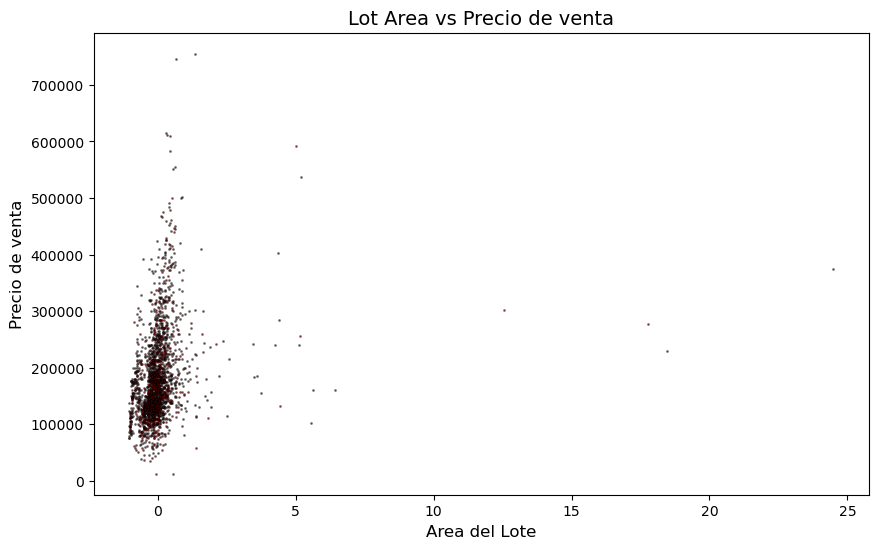

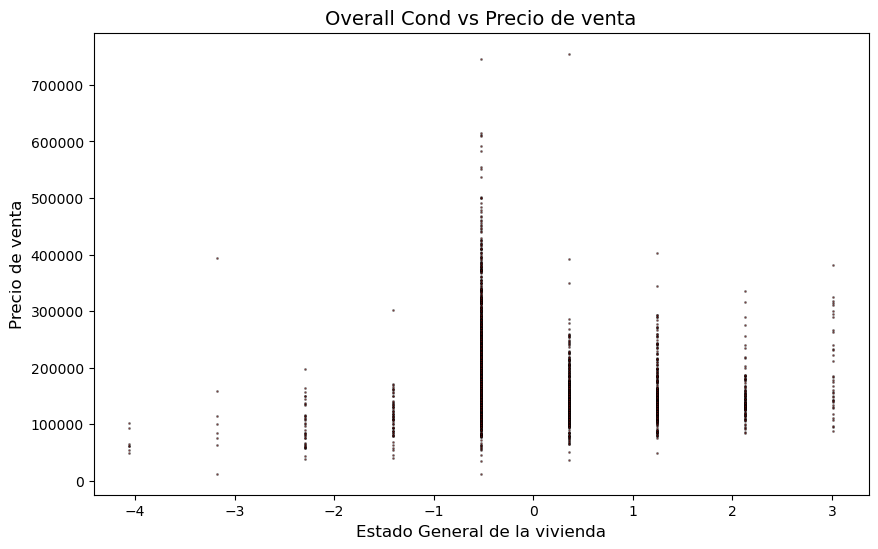

In [72]:
# Definir etiquetas para las primeras características
xlabel1 = 'Area del Lote'
xlabel2 = 'Estado General de la vivienda'
# xlabel3 = '3'
# xlabel4 = '4'
# xlabel5 = '5'
ylabel = 'Precio de venta'

plotData(X_norm[:, 3], y, xlabel1, ylabel)
plt.title(f'{feature_names[3]} vs {ylabel}', fontsize=14)
plt.show()

plotData(X_norm[:, 13], y, xlabel2, ylabel)
plt.title(f'{feature_names[13]} vs {ylabel}', fontsize=14)
plt.show()

# plotData(X_norm[:, 2], y, xlabel3, ylabel)
# plt.title(f'{feature_names[2]} vs {ylabel}', fontsize=14)
# plt.show()

# plotData(X_norm[:, 3], y, xlabel4, ylabel)
# plt.title(f'{feature_names[3]} vs {ylabel}', fontsize=14)
# plt.show()

# plotData(X_norm[:, 4], y, xlabel5, ylabel)
# plt.title(f'{feature_names[4]} vs {ylabel}', fontsize=14)
plt.show()

In [73]:
# Agregar columna de unos para el término de sesgo (beta_0)
m = y.size
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [74]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [75]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []
    P_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [76]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 4000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

theta calculado por el descenso por el gradiente: [ 1.77476412e+05 -2.57075113e+03 -2.01457152e+00  1.84303303e+03
  2.08654755e+03 -9.34683195e+02  1.44783484e+03  4.71981508e+02
  1.54839522e+03  2.38662622e+03  7.57797515e+01 -2.86918813e+03
 -1.86808463e+03  1.35826928e+04  4.45610061e+03  3.23122609e+03
  2.74887795e+03  1.88087183e+03  1.07758145e+03 -7.19146167e+02
 -5.88065571e+02  3.20102805e+03  5.44097525e+03 -8.36944922e+03
  1.17380746e+03  1.19428146e+03 -4.82044450e+03  2.43301865e+02
 -3.33373165e+03  1.33244432e+02  7.20254942e+03 -8.43389411e+02
  9.43314576e+03 -9.14952032e+02 -2.15669421e+03  8.73731186e+02
 -7.89868559e+02  4.65325277e+03  7.46361760e+03  9.70457150e+03
  2.43741532e+03 -7.38088756e+02  2.89257509e+03  2.60407050e+03
 -1.29671428e+03 -3.55596715e+03 -5.36577821e+03  3.96887287e+03
  2.59042941e+03  4.54252827e+03 -2.19154986e+03  1.81217931e+03
  5.27267876e+02 -2.60997874e+03  4.15893752e+03  4.77661414e+03
 -1.65814574e+03  1.58939271e+03  1.1991

Text(0.5, 1.0, 'Convergencia del Descenso por Gradiente')

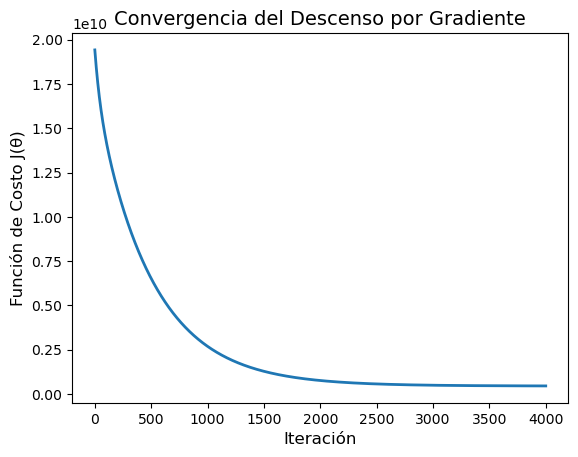

In [77]:
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Función de Costo J(θ)', fontsize=12)
plt.title('Convergencia del Descenso por Gradiente', fontsize=14)

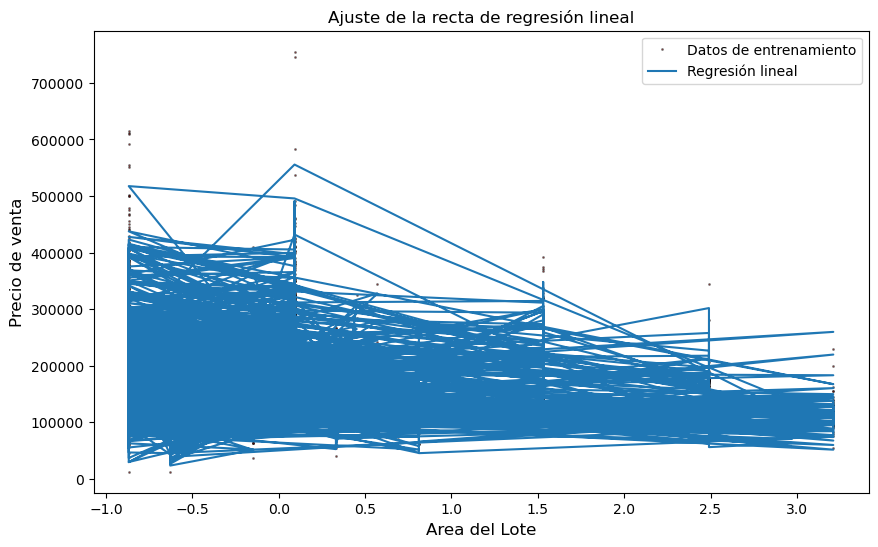

In [78]:
# Mostrar resultados de entrenamiento
plotData(X_norm[:,0], y, xlabel1, ylabel) # Graficar datos de entrenamiento
plt.plot(X_norm[:,0], np.dot(X, theta), '-') # Graficar la linea de regresion
plt.title('Ajuste de la recta de regresión lineal')
plt.legend(['Datos de entrenamiento', 'Regresión lineal'])

In [79]:
# Procesar y predecir con datos de prueba
m_test = y_test.size
x_test_pre = np.concatenate([np.ones((m_test, 1)), x_test], axis=1)
Y_pre = np.dot(x_test_pre, theta)
resultados = pd.DataFrame({
    'Valor_Real': y_test,
    'Prediccion': Y_pre
})
print("\nPrimeras filas del DataFrame 'resultados':")
print(resultados.head(10))


Primeras filas del DataFrame 'resultados':
      Valor_Real    Prediccion
2197       96500  4.660334e+07
2198      136500  5.454977e+07
2199      146500  4.784143e+07
2200      175000  6.028881e+07
2201      148500  3.901778e+07
2202      141500  4.868581e+07
2203      189950  5.182996e+07
2204      135000  5.091742e+07
2205      164000  5.704470e+07
2206       90350  3.339831e+07
